# EDA A/B-теста изменения карточки объявления

## Цель анализа

Проверяю, как выглядит A/B-тест после подготовки SQL-витрин. Команда изменила карточку объявления и кнопку контакта с продавцом. Главный вопрос: стала ли тестовая версия чаще доводить пользователя до контакта.

На этом шаге не делаю финальный статистический вывод. Здесь задача проще: проверить данные, баланс групп, сырые метрики и собрать чистый user-level датасет для статистики.

## Загрузка библиотек и данных

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.options.display.float_format = "{:.2f}".format
plt.style.use("default")

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
processed_dir = project_root / "data" / "processed"
figures_dir = project_root / "presentation" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

group_sizes = pd.read_csv(processed_dir / "01_group_sizes.csv")
event_funnel = pd.read_csv(processed_dir / "02_event_funnel.csv")
main_metrics = pd.read_csv(processed_dir / "03_main_metrics.csv")
user_metrics = pd.read_csv(processed_dir / "04_user_metrics.csv")
ab_test_dataset = pd.read_csv(processed_dir / "05_ab_test_dataset.csv")

datasets = {
    "01_group_sizes": group_sizes,
    "02_event_funnel": event_funnel,
    "03_main_metrics": main_metrics,
    "04_user_metrics": user_metrics,
    "05_ab_test_dataset": ab_test_dataset,
}


def format_money(value):
    return f"{value:.2f}"


def format_percent(value):
    return f"{value:.2%}"


def format_pp(value):
    return f"{value * 100:.2f} п.п."


def display_percent_table(table, percent_columns):
    formatted = table.copy()
    for column in percent_columns:
        if column in formatted.columns:
            formatted[column] = formatted[column].map(format_percent)
    display(formatted)

print("Данные загружены.")

Данные загружены.


## Первичная проверка данных

Сначала проверяю базовую гигиену: размеры таблиц, типы, пропуски и дубли. Если здесь есть проблема, дальше метрики могут быть красивыми, но бесполезными.

In [2]:
for dataset_name, dataset in datasets.items():
    print(f"\n=== {dataset_name} ===")
    print(f"Размер: {dataset.shape[0]} строк, {dataset.shape[1]} столбцов")
    display(dataset.head())
    display(dataset.dtypes.to_frame("dtype"))
    display(dataset.isna().sum().to_frame("missing_values"))
    print(f"Полные дубли строк: {dataset.duplicated().sum()}")
    if "user_id" in dataset.columns:
        print(f"Дубли user_id: {dataset['user_id'].duplicated().sum()}")


=== 01_group_sizes ===
Размер: 2 строк, 3 столбцов


,experiment_group,users_count,users_share
0,control,6000,0.50
1,test,6000,0.50


,dtype
experiment_group,object
users_count,int64
users_share,float64


,missing_values
experiment_group,0
users_count,0
users_share,0


Полные дубли строк: 0

=== 02_event_funnel ===
Размер: 2 строк, 8 столбцов


...

Полные дубли строк: 0
Дубли user_id: 0

=== 05_ab_test_dataset ===
Размер: 12000 строк, 13 столбцов


,user_id,experiment_group,region,device,user_segment,views,favorites,contacts,purchases,revenue,has_contact,has_purchase,is_payer
0,1,control,Ural,android,regular,5,1,1,0,499.00,1,0,1
1,2,control,Moscow,desktop,regular,8,0,0,0,0.00,0,0,0
2,3,control,Siberia,mobile_web,bargain_hunter,9,2,1,0,0.00,1,0,0
3,4,control,Moscow,android,new,6,0,0,0,0.00,0,0,0
4,5,control,Moscow,desktop,new,3,0,0,0,0.00,0,0,0


,dtype
user_id,int64
experiment_group,object
region,object
device,object
user_segment,object
views,int64
favorites,int64
contacts,int64
purchases,int64
revenue,float64


,missing_values
user_id,0
experiment_group,0
region,0
device,0
user_segment,0
views,0
favorites,0
contacts,0
purchases,0
revenue,0


Полные дубли строк: 0
Дубли user_id: 0


Данные выглядят аккуратно: пользовательские витрины идут по одной строке на пользователя, пропусков нет. Это хороший старт для A/B-теста.

## Проверка дизайна эксперимента

Теперь смотрю, не развалился ли дизайн эксперимента. Нужны близкие размеры групп и похожий состав пользователей по региону, устройству и сегменту.

In [3]:
display_percent_table(group_sizes, ["users_share"])

calculated_group_sizes = (
    ab_test_dataset
    .groupby("experiment_group", as_index=False)
    .agg(users_count=("user_id", "nunique"))
)
calculated_group_sizes["users_share"] = calculated_group_sizes["users_count"] / calculated_group_sizes["users_count"].sum()
display_percent_table(calculated_group_sizes, ["users_share"])


def distribution_by_group(data, column):
    # Посчитать доли категорий внутри каждой группы эксперимента.
    return pd.crosstab(data[column], data["experiment_group"], normalize="columns")

for column in ["region", "device", "user_segment"]:
    print(f"\nРаспределение: {column}")
    distribution = distribution_by_group(ab_test_dataset, column).reset_index()
    display_percent_table(distribution, ["control", "test"])


,experiment_group,users_count,users_share
0,control,6000,50.00%
1,test,6000,50.00%


,experiment_group,users_count,users_share
0,control,6000,50.00%
1,test,6000,50.00%



Распределение: region


experiment_group,region,control,test
0,Moscow,23.35%,24.48%
1,Saint Petersburg,16.25%,15.35%
2,Siberia,15.55%,15.13%
3,South,13.30%,13.32%
4,Ural,14.65%,14.73%
5,Volga,16.90%,16.98%



Распределение: device


experiment_group,device,control,test
0,android,40.67%,42.57%
1,desktop,23.53%,22.93%
2,ios,24.75%,24.28%
3,mobile_web,11.05%,10.22%



Распределение: user_segment


experiment_group,user_segment,control,test
0,bargain_hunter,17.92%,18.50%
1,new,27.65%,28.57%
2,power_seller,9.13%,9.10%
3,regular,45.30%,43.83%


Группы одинаковые по размеру: 50.00% на 50.00%. По региону, устройству и сегменту нет заметного перекоса. Для учебного A/B-теста дизайн выглядит нормально.

## Анализ воронки

Смотрю путь пользователя от просмотра объявления к избранному, контакту и покупке. Для этой фичи главный интерес — контакт после просмотра.

In [4]:
funnel_display = event_funnel.copy()
rate_columns = ["favorite_rate_from_view", "contact_rate_from_view", "purchase_rate_from_view"]
display_percent_table(funnel_display, rate_columns)

rate_comparison = event_funnel.set_index("experiment_group")[rate_columns].T
rate_comparison["absolute_diff_test_vs_control"] = rate_comparison["test"] - rate_comparison["control"]
rate_comparison["relative_diff_test_vs_control"] = rate_comparison["absolute_diff_test_vs_control"] / rate_comparison["control"]
rate_comparison_display = rate_comparison.reset_index().rename(columns={"index": "metric"})
display_percent_table(
    rate_comparison_display,
    ["control", "test", "absolute_diff_test_vs_control", "relative_diff_test_vs_control"],
)

,experiment_group,views,favorites,contacts,purchases,favorite_rate_from_view,contact_rate_from_view,purchase_rate_from_view
0,control,40619,1951,2059,120,4.80%,5.07%,0.30%
1,test,40714,2030,2282,110,4.99%,5.60%,0.27%


experiment_group,metric,control,test,absolute_diff_test_vs_control,relative_diff_test_vs_control
0,favorite_rate_from_view,4.80%,4.99%,0.19%,3.96%
1,contact_rate_from_view,5.07%,5.60%,0.53%,10.45%
2,purchase_rate_from_view,0.30%,0.27%,-0.03%,-10.00%


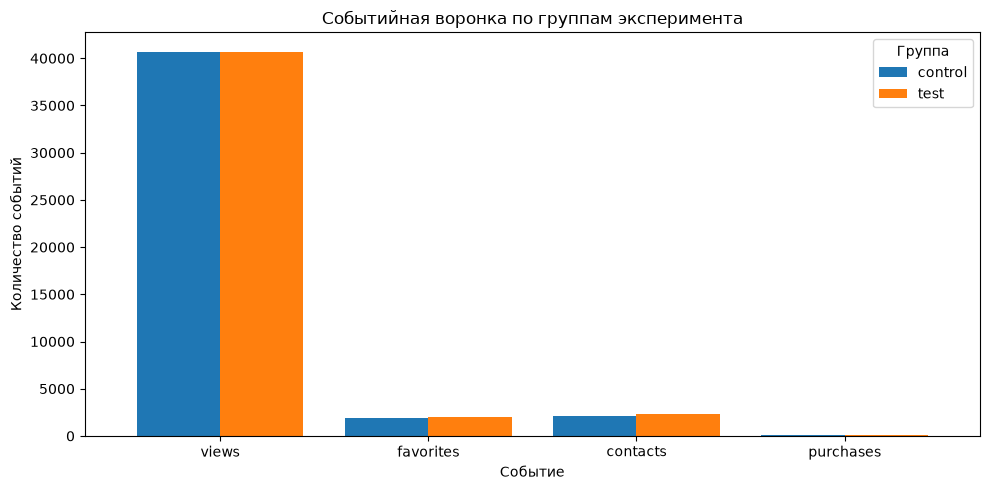

In [5]:
funnel_count_columns = ["views", "favorites", "contacts", "purchases"]
plot_data = event_funnel.set_index("experiment_group")[funnel_count_columns].T

ax = plot_data.plot(kind="bar", figsize=(10, 5), width=0.8)
ax.set_title("Событийная воронка по группам эксперимента")
ax.set_xlabel("Событие")
ax.set_ylabel("Количество событий")
ax.legend(title="Группа")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(figures_dir / "01_funnel_event_counts.png", dpi=150)
plt.show()

По количеству событий группы сопоставимы. Контактов в test больше, но пока это только сырое наблюдение: статистику проверю в следующем ноутбуке.

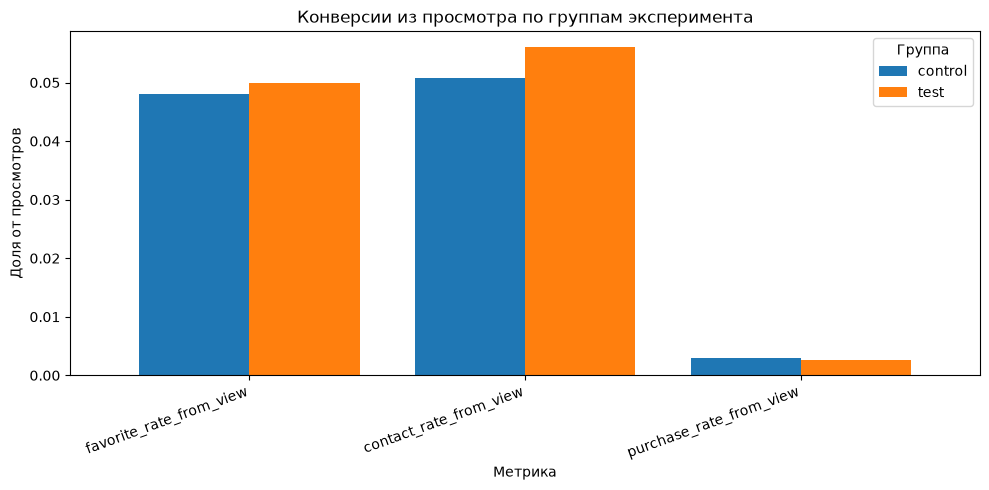

In [6]:
plot_rates = event_funnel.set_index("experiment_group")[rate_columns].T

ax = plot_rates.plot(kind="bar", figsize=(10, 5), width=0.8)
ax.set_title("Конверсии из просмотра по группам эксперимента")
ax.set_xlabel("Метрика")
ax.set_ylabel("Доля от просмотров")
ax.legend(title="Группа")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(figures_dir / "02_funnel_conversion_rates.png", dpi=150)
plt.show()

Конверсия в контакт из просмотра выше в тестовой группе. Это ровно та метрика, на которую должна была повлиять новая карточка.

## Анализ основных метрик

Сравниваю агрегаты из SQL: пользователей, просмотры, контакты, покупки, платящих пользователей, выручку и конверсии.

In [7]:
main_metrics_display = main_metrics.copy()
percent_columns = [
    "contact_conversion_per_user",
    "purchase_conversion_per_user",
    "contact_rate_from_view",
    "purchase_rate_from_view",
]
for column in ["revenue", "arpu", "arppu"]:
    main_metrics_display[column] = main_metrics_display[column].map(format_money)
display_percent_table(main_metrics_display, percent_columns)

main_metrics_comparison = main_metrics.set_index("experiment_group").T
main_metrics_comparison["absolute_diff_test_vs_control"] = main_metrics_comparison["test"] - main_metrics_comparison["control"]
main_metrics_comparison["relative_diff_test_vs_control"] = (
    main_metrics_comparison["absolute_diff_test_vs_control"] / main_metrics_comparison["control"].replace(0, np.nan)
)
comparison_display = main_metrics_comparison.reset_index().rename(columns={"index": "metric"})
display(comparison_display.round(4))

,experiment_group,users_count,views,contacts,purchases,paying_users,revenue,contact_conversion_per_user,purchase_conversion_per_user,contact_rate_from_view,purchase_rate_from_view,arpu,arppu
0,control,6000,40619,2059,120,225,84042.00,28.60%,1.95%,5.07%,0.30%,14.01,373.52
1,test,6000,40714,2282,110,218,90530.00,30.60%,1.80%,5.60%,0.27%,15.09,415.28


experiment_group,metric,control,test,absolute_diff_test_vs_control,relative_diff_test_vs_control
0,users_count,6000.00,6000.00,0.00,0.00
1,views,40619.00,40714.00,95.00,0.00
2,contacts,2059.00,2282.00,223.00,0.11
3,purchases,120.00,110.00,-10.00,-0.08
4,paying_users,225.00,218.00,-7.00,-0.03
5,revenue,84042.00,90530.00,6488.00,0.08
6,contact_conversion_per_user,0.29,0.31,0.02,0.07
7,purchase_conversion_per_user,0.02,0.02,-0.00,-0.08
8,contact_rate_from_view,0.05,0.06,0.01,0.10
9,purchase_rate_from_view,0.00,0.00,-0.00,-0.10


Главный сигнал снова в контактах: test лучше по доле пользователей с контактом и по контактам от просмотров. По выручке видна небольшая разница, но денежные метрики обычно шумят сильнее.

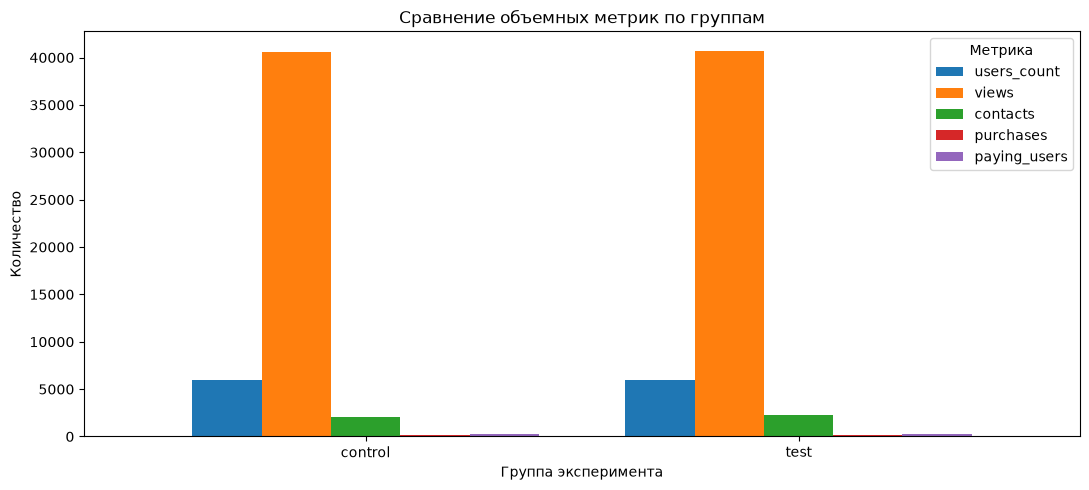

In [8]:
count_metrics = ["users_count", "views", "contacts", "purchases", "paying_users"]
ax = main_metrics.set_index("experiment_group")[count_metrics].plot(kind="bar", figsize=(11, 5), width=0.8)
ax.set_title("Сравнение объемных метрик по группам")
ax.set_xlabel("Группа эксперимента")
ax.set_ylabel("Количество")
ax.legend(title="Метрика")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(figures_dir / "03_main_count_metrics.png", dpi=150)
plt.show()

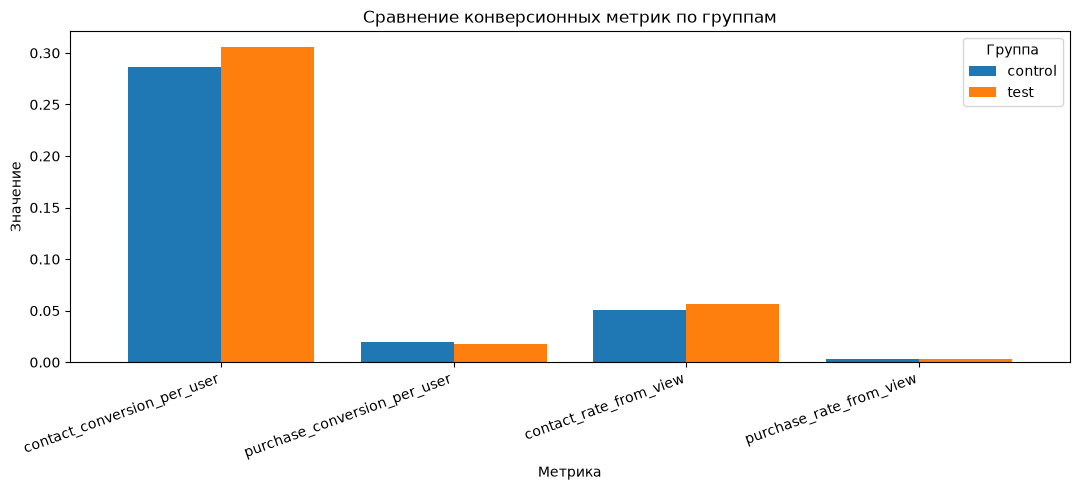

In [9]:
conversion_metrics = [
    "contact_conversion_per_user",
    "purchase_conversion_per_user",
    "contact_rate_from_view",
    "purchase_rate_from_view",
]
ax = main_metrics.set_index("experiment_group")[conversion_metrics].T.plot(kind="bar", figsize=(11, 5), width=0.8)
ax.set_title("Сравнение конверсионных метрик по группам")
ax.set_xlabel("Метрика")
ax.set_ylabel("Значение")
ax.legend(title="Группа")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(figures_dir / "04_main_conversion_metrics.png", dpi=150)
plt.show()

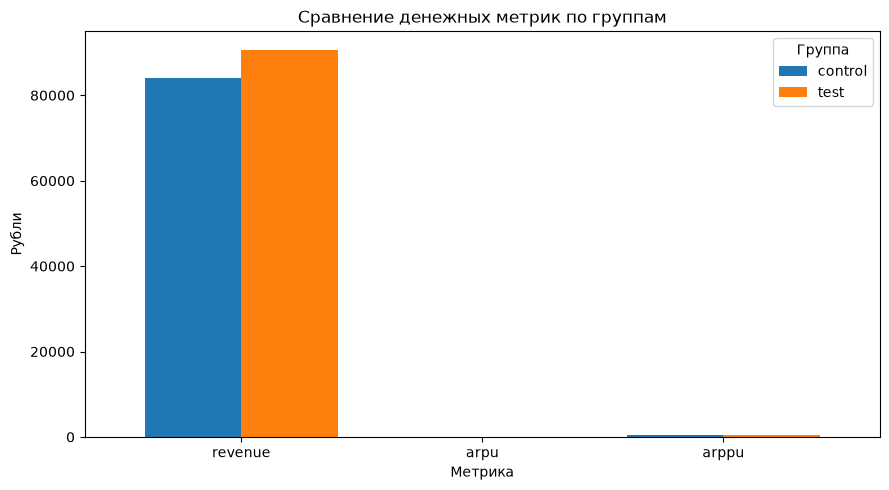

In [10]:
money_metrics = ["revenue", "arpu", "arppu"]
ax = main_metrics.set_index("experiment_group")[money_metrics].T.plot(kind="bar", figsize=(9, 5), width=0.8)
ax.set_title("Сравнение денежных метрик по группам")
ax.set_xlabel("Метрика")
ax.set_ylabel("Рубли")
ax.legend(title="Группа")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(figures_dir / "05_money_metrics.png", dpi=150)
plt.show()

Денежные метрики лучше не переоценивать по одному графику. Платежей мало, поэтому среднее может меняться из-за небольшого числа пользователей.

## User-level EDA

Перехожу к уровню пользователя. Для статистики это ключевая витрина: один пользователь — одна строка.

experiment_group  control    test
views     count   6000.00 6000.00
          mean       6.77    6.79
          std        3.48    3.49
          min        1.00    1.00
          25%        4.00    4.00
          50%        6.00    6.00
          75%        9.00    9.00
          max       21.00   24.00
favorites count   6000.00 6000.00
          mean       0.33    0.34
          std        0.58    0.60
          min        0.00    0.00
          25%        0.00    0.00
          50%        0.00    0.00
          75%        1.00    1.00
          max        4.00    5.00
contacts  count   6000.00 6000.00
          mean       0.34    0.38
          std        0.59    0.64
          min        0.00    0.00
          25%        0.00    0.00
          50%        0.00    0.00
          75%        1.00    1.00
          max        4.00    5.00
purchases count   6000.00 6000.00
          mean       0.02    0.02
          std        0.14    0.14
          min        0.00    0.00
          25%        0.00    0.00
          50%        0.00    0.00
          75%        0.00    0.00
          max        2.00    2.00
revenue   count   6000.00 6000.00
          mean      14.01   15.09
          std       89.41   96.26
          min        0.00    0.00
          25%        0.00    0.00
          50%        0.00    0.00
          75%        0.00    0.00
          max     1298.00 1498.00

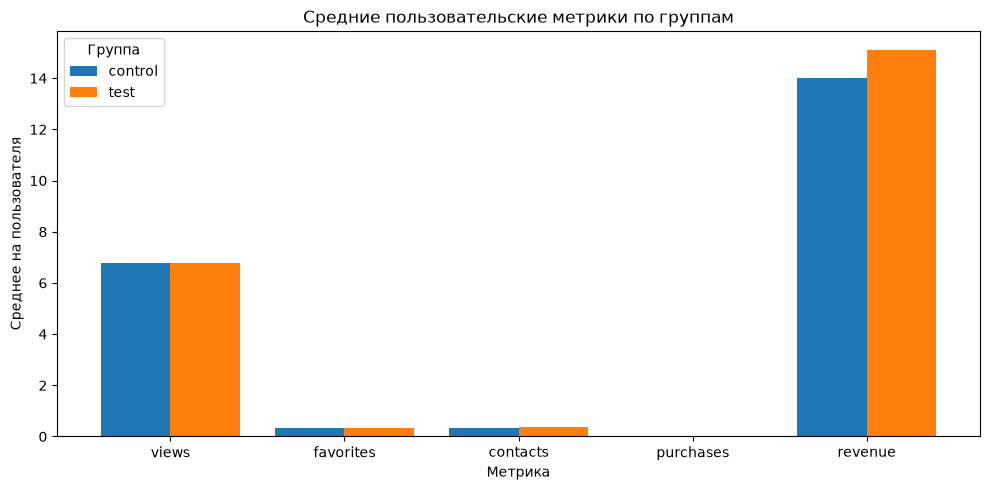

In [11]:
user_numeric_columns = ["views", "favorites", "contacts", "purchases", "revenue"]
user_descriptive_stats = ab_test_dataset.groupby("experiment_group")[user_numeric_columns].describe().T
display(user_descriptive_stats.round(2))

mean_user_metrics = ab_test_dataset.groupby("experiment_group")[user_numeric_columns].mean()
ax = mean_user_metrics.T.plot(kind="bar", figsize=(10, 5), width=0.8)
ax.set_title("Средние пользовательские метрики по группам")
ax.set_xlabel("Метрика")
ax.set_ylabel("Среднее на пользователя")
ax.legend(title="Группа")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(figures_dir / "06_user_mean_metrics.png", dpi=150)
plt.show()

На уровне пользователя test тоже выше по контактам. Просмотры почти не отличаются, поэтому рост контактов не выглядит как простой результат большего трафика.

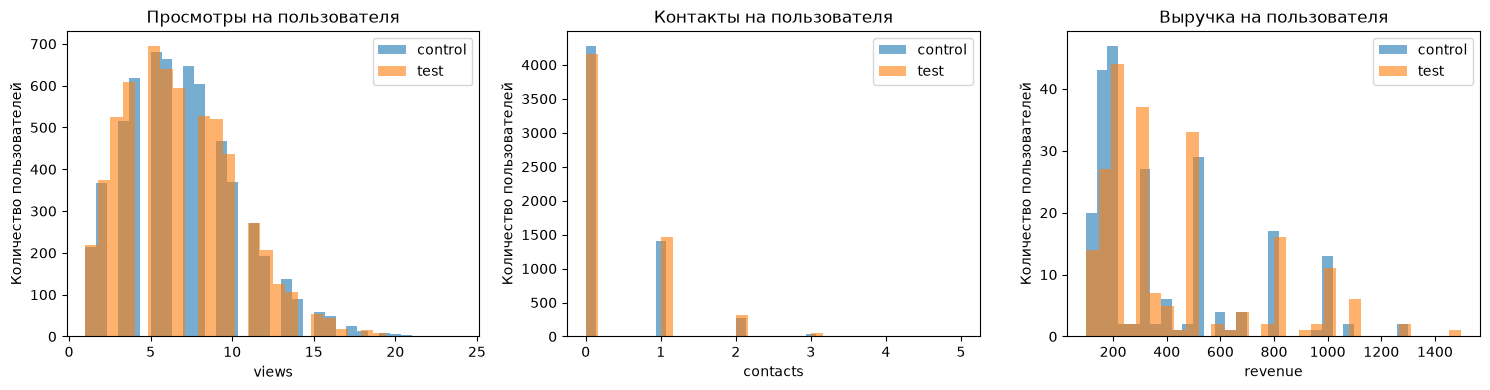

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, title in zip(
    axes,
    ["views", "contacts", "revenue"],
    ["Просмотры на пользователя", "Контакты на пользователя", "Выручка на пользователя"],
):
    for group_name, group_data in ab_test_dataset.groupby("experiment_group"):
        values = group_data[metric]
        if metric == "revenue":
            values = values[values > 0]
        ax.hist(values, bins=30, alpha=0.6, label=group_name)
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("Количество пользователей")
    ax.legend()

plt.tight_layout()
plt.savefig(figures_dir / "07_user_metric_distributions.png", dpi=150)
plt.show()

Распределения типичные для продукта: много пользователей с небольшой активностью и небольшой хвост активных пользователей. Выручка разреженная: большинство пользователей ничего не платит.

,experiment_group,has_contact,has_purchase,is_payer
0,control,28.60%,1.95%,3.75%
1,test,30.60%,1.80%,3.63%


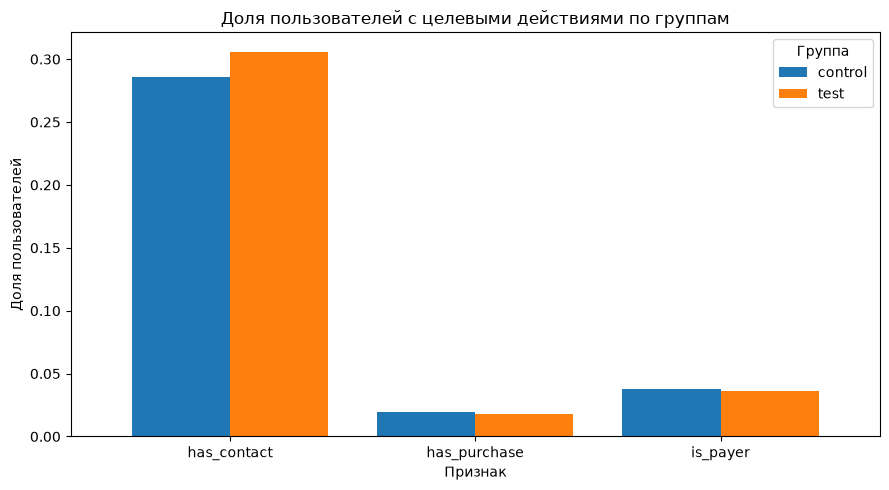

In [13]:
flag_columns = ["has_contact", "has_purchase", "is_payer"]
flag_shares = ab_test_dataset.groupby("experiment_group")[flag_columns].mean().reset_index()
display_percent_table(flag_shares, flag_columns)

ax = flag_shares.set_index("experiment_group")[flag_columns].T.plot(kind="bar", figsize=(9, 5), width=0.8)
ax.set_title("Доля пользователей с целевыми действиями по группам")
ax.set_xlabel("Признак")
ax.set_ylabel("Доля пользователей")
ax.legend(title="Группа")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(figures_dir / "08_binary_flag_shares.png", dpi=150)
plt.show()

Доля пользователей с контактом выше в test. По покупке и платежам явного сильного сдвига не видно.

In [14]:
revenue_summary = (
    ab_test_dataset
    .assign(has_revenue=lambda data: data["revenue"] > 0)
    .groupby("experiment_group")
    .agg(
        users_count=("user_id", "nunique"),
        payers=("has_revenue", "sum"),
        payer_share=("has_revenue", "mean"),
        revenue_mean=("revenue", "mean"),
        revenue_median=("revenue", "median"),
        revenue_p95=("revenue", lambda values: values.quantile(0.95)),
        revenue_max=("revenue", "max"),
    )
    .reset_index()
)
revenue_summary_display = revenue_summary.copy()
revenue_summary_display["payer_share"] = revenue_summary_display["payer_share"].map(format_percent)
for column in ["revenue_mean", "revenue_median", "revenue_p95", "revenue_max"]:
    revenue_summary_display[column] = revenue_summary_display[column].map(format_money)
display(revenue_summary_display)

,experiment_group,users_count,payers,payer_share,revenue_mean,revenue_median,revenue_p95,revenue_max
0,control,6000,225,3.75%,14.01,0.00,0.00,1298.00
1,test,6000,218,3.63%,15.09,0.00,0.00,1498.00


Выручка скошена: медиана равна 0.00, потому что большинство пользователей не платит. Поэтому ARPU надо проверять аккуратнее, лучше через bootstrap.

## Предварительные гипотезы

**Контактная конверсия**

- H0: доля пользователей с контактом одинакова в control и test.
- H1: доля пользователей с контактом отличается между control и test.

**ARPU**

- H0: средняя выручка на пользователя одинакова в control и test.
- H1: средняя выручка на пользователя отличается между control и test.

## Подготовка данных для статистики

Собираю компактный датасет для следующего шага. Здесь должны остаться только нужные поля, без дублей пользователей и с бинарными флагами 0/1.

In [15]:
stats_columns = [
    "user_id",
    "experiment_group",
    "has_contact",
    "has_purchase",
    "is_payer",
    "revenue",
    "views",
    "contacts",
    "purchases",
    "region",
    "device",
    "user_segment",
]

stats_dataset = ab_test_dataset[stats_columns].copy()

numeric_columns = ["has_contact", "has_purchase", "is_payer", "revenue", "views", "contacts", "purchases"]
binary_columns = ["has_contact", "has_purchase", "is_payer"]

# Заполнить числовые пропуски и привести флаги к 0/1.
stats_dataset[numeric_columns] = stats_dataset[numeric_columns].fillna(0)
stats_dataset[binary_columns] = stats_dataset[binary_columns].astype(int)
stats_dataset["views"] = stats_dataset["views"].astype(int)
stats_dataset["contacts"] = stats_dataset["contacts"].astype(int)
stats_dataset["purchases"] = stats_dataset["purchases"].astype(int)
stats_dataset["revenue"] = stats_dataset["revenue"].astype(float)

# Оставить только ожидаемые группы эксперимента.
stats_dataset = stats_dataset[stats_dataset["experiment_group"].isin(["control", "test"])].copy()

assert stats_dataset["user_id"].duplicated().sum() == 0, "В датасете есть дубли user_id"
assert stats_dataset[numeric_columns].isna().sum().sum() == 0, "В числовых полях есть пропуски"
assert set(stats_dataset["experiment_group"].unique()) == {"control", "test"}, "Неожиданные значения experiment_group"
for column in binary_columns:
    assert set(stats_dataset[column].unique()).issubset({0, 1}), f"Неожиданные значения в {column}"

output_path = processed_dir / "ab_test_ready_for_stats.csv"
stats_dataset.to_csv(output_path, index=False)

print(f"Файл сохранен: {output_path.relative_to(project_root)}")
print(f"Размер: {stats_dataset.shape[0]} строк, {stats_dataset.shape[1]} столбцов")
display(stats_dataset.head())

Файл сохранен: data\processed\ab_test_ready_for_stats.csv
Размер: 12000 строк, 12 столбцов


,user_id,experiment_group,has_contact,has_purchase,is_payer,revenue,views,contacts,purchases,region,device,user_segment
0,1,control,1,0,1,499.00,5,1,0,Ural,android,regular
1,2,control,0,0,0,0.00,8,0,0,Moscow,desktop,regular
2,3,control,1,0,0,0.00,9,1,0,Siberia,mobile_web,bargain_hunter
3,4,control,0,0,0,0.00,6,0,0,Moscow,android,new
4,5,control,0,0,0,0.00,3,0,0,Moscow,desktop,new


## EDA conclusions

- Дизайн эксперимента выглядит сбалансированным: группы одинаковые по размеру и похожи по ключевым пользовательским признакам.
- В test выше сырая контактная конверсия и среднее число контактов на пользователя.
- По покупкам, платежам и выручке сильного визуального эффекта нет.
- Выручка разреженная и скошенная, поэтому средний ARPU может шуметь.
- Следующий шаг — статистически проверить `has_contact` и ARPU. До этого сырые различия остаются наблюдением, а не продуктовым решением.